Data loaded: 5000 rows, 21 columns
First 5 rows:

Data types:

Missing values:


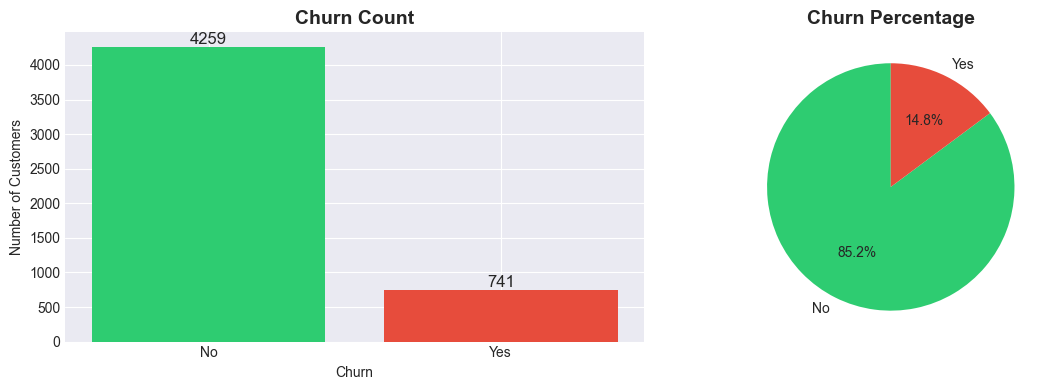

✅ Churn rate: 14.8%


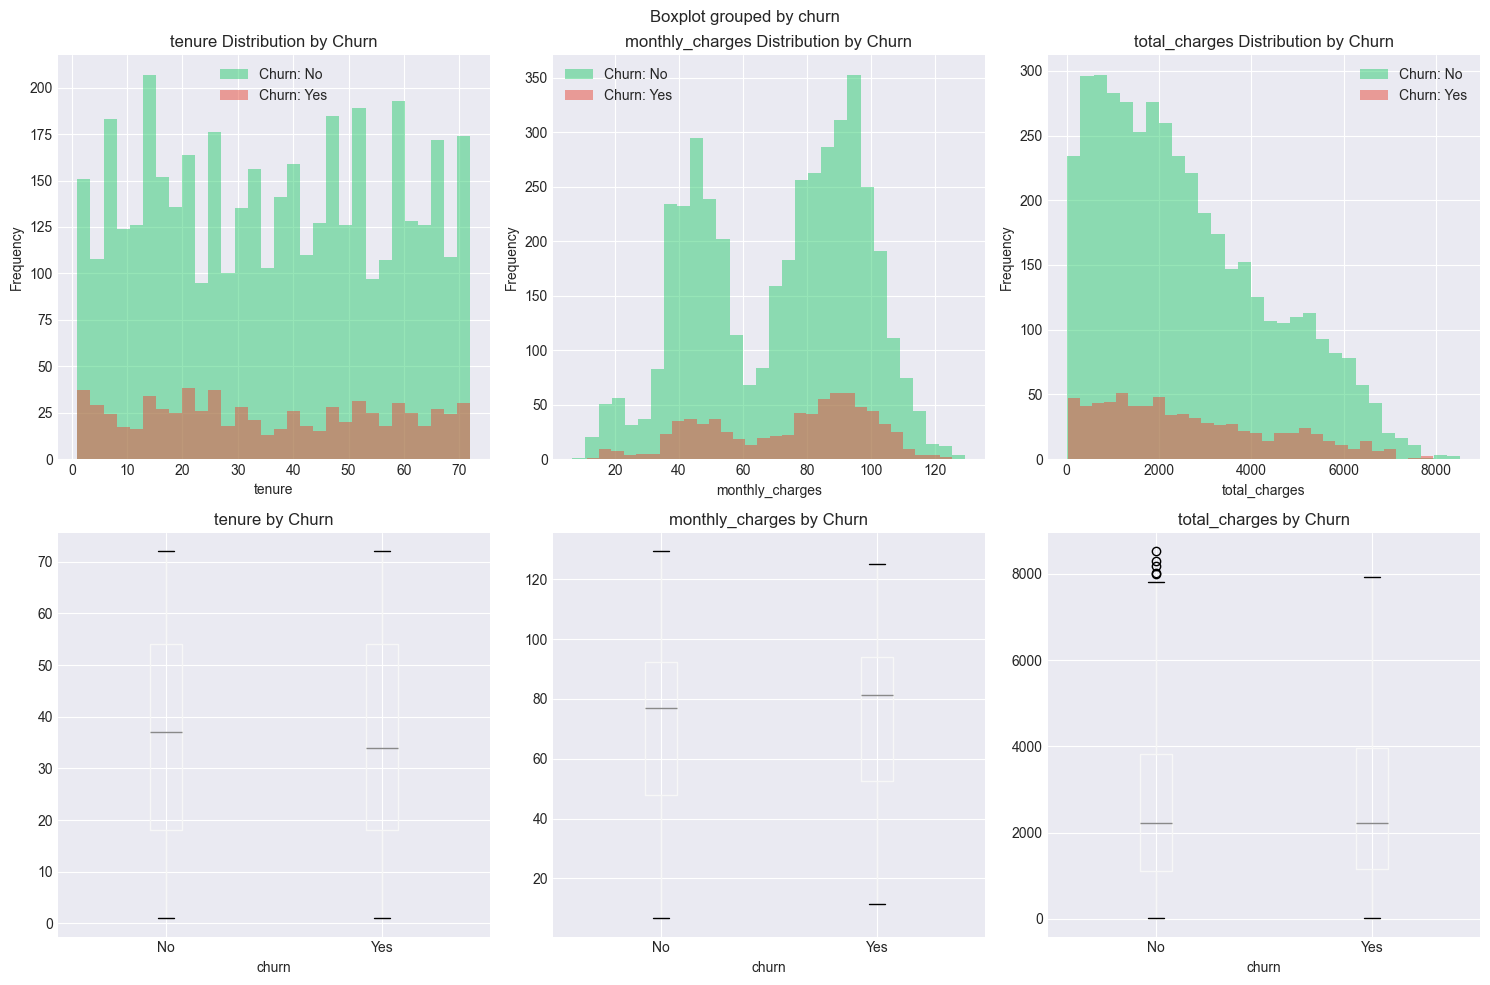

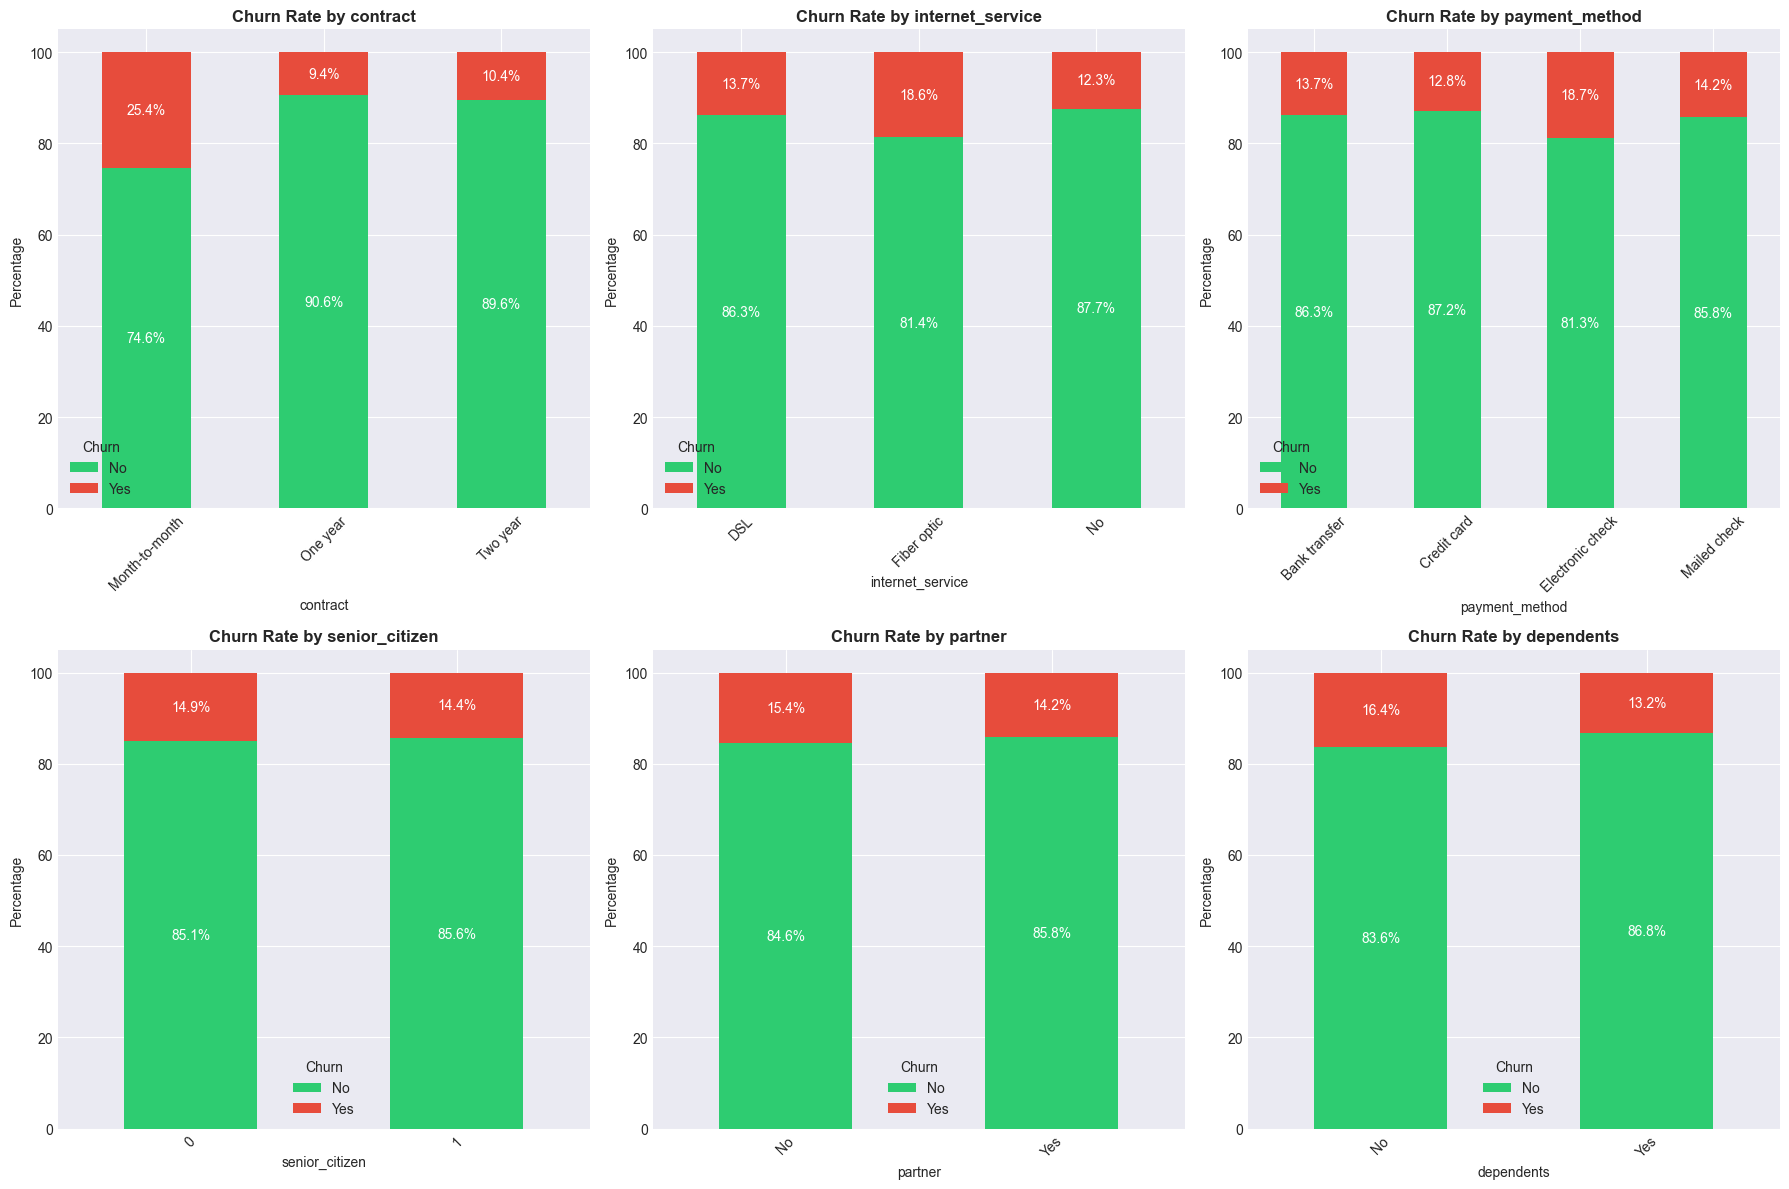

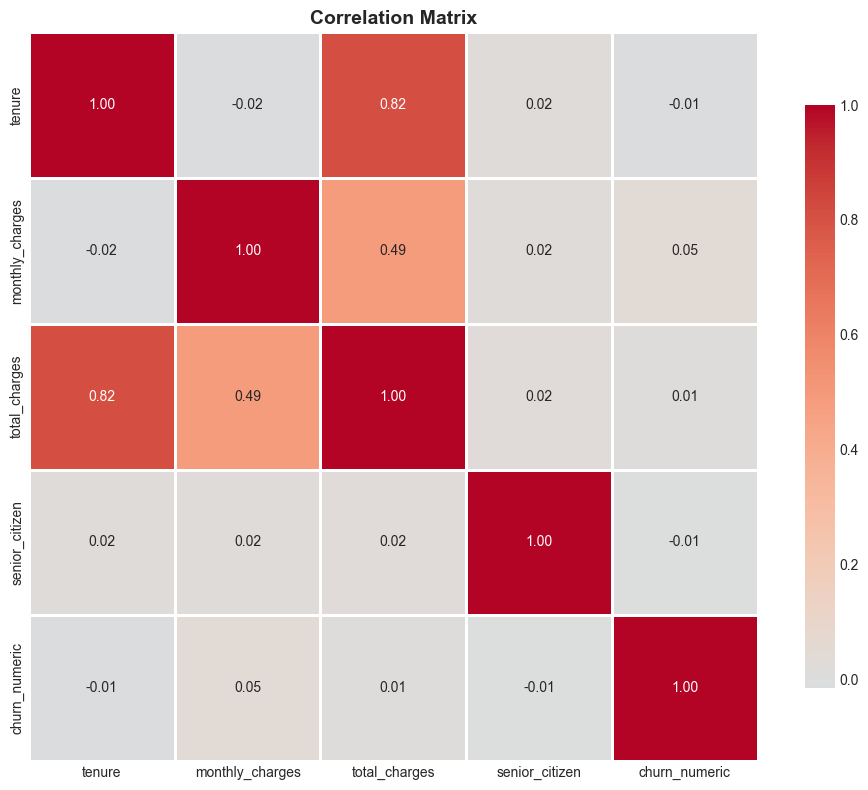

KEY FINDINGS SUMMARY
1. Overall churn rate: 14.8%

2. High Risk Factors:
   • Month-to-month contracts
   • Short tenure (< 6 months)
   • Fiber optic internet
   • Electronic check payment

3. Low Risk Factors:
   • Long-term contracts (1-2 years)
   • Having dependents
   • Having a partner
   • Longer tenure

4. Next Steps:
   • Build predictive model
   • Feature engineering
   • Model evaluation


In [1]:
# %% [markdown]
# # Customer Churn Prediction - Exploratory Data Analysis
# ## Understanding what drives customer churn

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
df = pd.read_csv('../data/customer_churn_data.csv')
print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# %% [markdown]
# ### 1. First Look at the Data

# %% [code]
print("First 5 rows:")
df.head()

# %% [code]
print("\nData types:")
df.dtypes

# %% [code]
print("\nMissing values:")
df.isnull().sum()

# %% [markdown]
# ### 2. Target Variable: Churn Distribution

# %% [code]
churn_counts = df['churn'].value_counts()
churn_pcts = df['churn'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')

# Add labels
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

# Pie chart
axes[1].pie(churn_pcts.values, labels=churn_pcts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✅ Churn rate: {churn_pcts['Yes']:.1%}")

# %% [markdown]
# ### 3. Numeric Features Analysis

# %% [code]
numeric_cols = ['tenure', 'monthly_charges', 'total_charges']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(numeric_cols):
    # Histograms by churn
    for churn_val, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
        subset = df[df['churn'] == churn_val][col]
        axes[0, i].hist(subset, bins=30, alpha=0.5, label=f'Churn: {churn_val}', color=color)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].set_title(f'{col} Distribution by Churn')
    axes[0, i].legend()
    
    # Box plots
    df.boxplot(column=col, by='churn', ax=axes[1, i])
    axes[1, i].set_title(f'{col} by Churn')

plt.tight_layout()
plt.savefig('../results/numeric_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### Key Insights from Numeric Features:
# - **Tenure**: Customers who churn tend to have shorter tenure
# - **Monthly Charges**: Higher monthly charges may lead to more churn
# - **Total Charges**: Correlated with tenure, but churners have lower total

# %% [markdown]
# ### 4. Categorical Features Analysis

# %% [code]
categorical_cols = ['contract', 'internet_service', 'payment_method', 
                    'senior_citizen', 'partner', 'dependents']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Create crosstab
    ct = pd.crosstab(df[col], df['churn'], normalize='index') * 100
    
    # Plot
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage')
    axes[i].legend(title='Churn')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    for j, (idx, row) in enumerate(ct.iterrows()):
        axes[i].text(j, row['No']/2, f"{row['No']:.1f}%", 
                    ha='center', va='center', fontsize=10, color='white')
        axes[i].text(j, row['No'] + row['Yes']/2, f"{row['Yes']:.1f}%", 
                    ha='center', va='center', fontsize=10, color='white')

plt.tight_layout()
plt.savefig('../results/categorical_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### Key Insights from Categorical Features:
# - **Contract**: Month-to-month customers churn much more
# - **Internet Service**: Fiber optic has higher churn
# - **Payment Method**: Electronic check users churn more
# - **Senior Citizens**: Slightly lower churn rate
# - **Dependents/Partner**: Customers with family churn less

# %% [markdown]
# ### 5. Correlation Analysis

# %% [code]
# Convert target to numeric
df_numeric = df.copy()
df_numeric['churn_numeric'] = (df_numeric['churn'] == 'Yes').astype(int)

# Select numeric columns
numeric_df = df_numeric[['tenure', 'monthly_charges', 'total_charges', 
                         'senior_citizen', 'churn_numeric']]

# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 6. Key Findings Summary

# %% [code]
print("="*60)
print("KEY FINDINGS SUMMARY")
print("="*60)
print(f"1. Overall churn rate: {churn_pcts['Yes']:.1%}")
print("\n2. High Risk Factors:")
print("   • Month-to-month contracts")
print("   • Short tenure (< 6 months)")
print("   • Fiber optic internet")
print("   • Electronic check payment")
print("\n3. Low Risk Factors:")
print("   • Long-term contracts (1-2 years)")
print("   • Having dependents")
print("   • Having a partner")
print("   • Longer tenure")
print("\n4. Next Steps:")
print("   • Build predictive model")
print("   • Feature engineering")
print("   • Model evaluation")
print("="*60)